# Analisis y prediccion con series de tiempo

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from sklearn.model_selection import train_test_split
import yfinance as yf


## Sobre los datos

---

Para esta sesión usaremos un conjunto de datos que contiene información histórica de precios de las acciones de **Apple Inc. (AAPL)** descargados desde *Yahoo Finance*. Incluye registros diarios desde el **1 de enero de 2015** hasta el **1 de enero de 2025**, con variables como el precio de apertura (*Open*), el precio máximo (*High*), el precio mínimo (*Low*), el precio de cierre (*Close*), el precio ajustado (*Adj Close*) y el volumen de transacciones (*Volume*).


In [3]:
# Descargar Apple desde 2015
data_raw = yf.download("AAPL", start="2015-01-01", end="2025-01-01")

C:\Users\roman\AppData\Local\Temp\ipykernel_380\148012674.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Observemos los datos diarios con diferentes suavizamientos. 

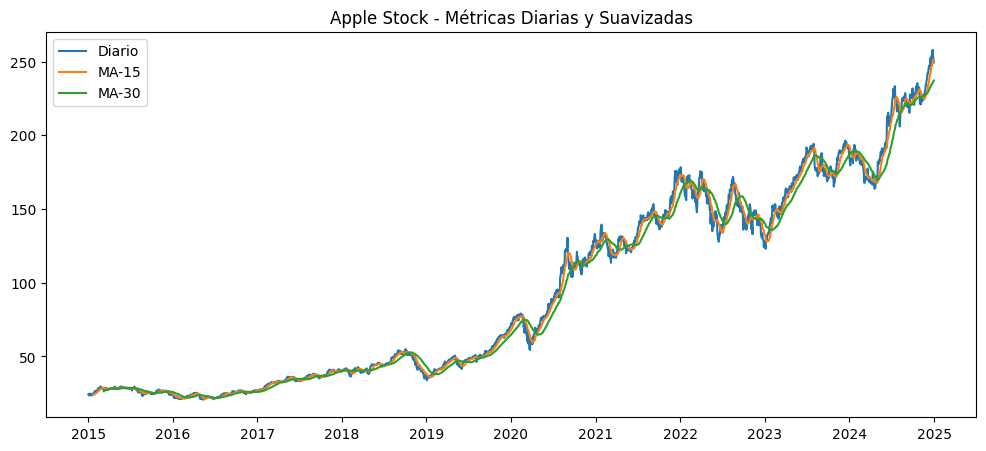

In [4]:
plt.figure(figsize=(12,5))
plt.plot(data_raw['Close'], label="Diario")
plt.plot(data_raw['Close'].rolling(window=15).mean(), label="MA-15")
plt.plot(data_raw['Close'].rolling(window=45).mean(), label="MA-30")
plt.legend()
plt.title("Apple Stock - Métricas Diarias y Suavizadas")
plt.show()

🤔 **Analicemos la serie**

* *¿Qué características observas en la serie?*

### Resampleo y suavizado de los datos

---

**Semanal**

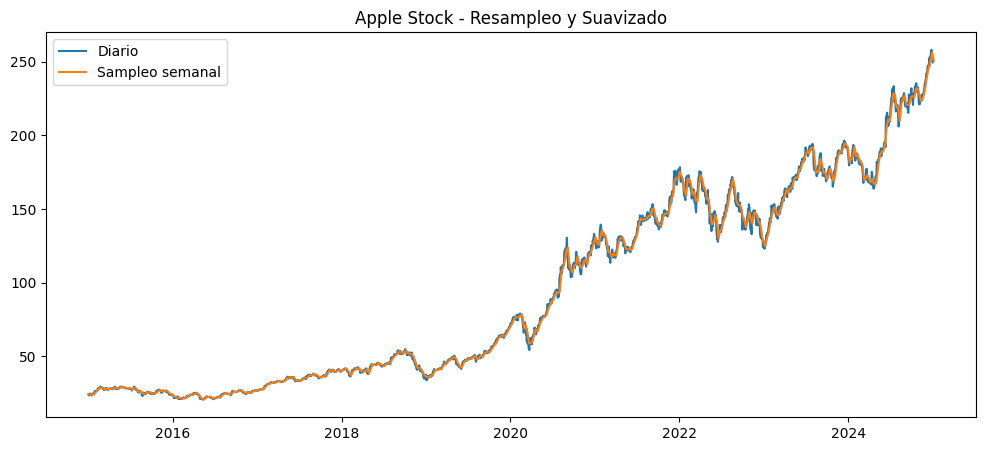

In [5]:
plt.figure(figsize=(12,5))
plt.plot(data_raw['Close'], label="Diario")
plt.plot(data_raw['Close'].resample('W').mean(), label="Sampleo semanal")
plt.legend()
plt.title("Apple Stock - Resampleo y Suavizado")
plt.show()

**Mensual**

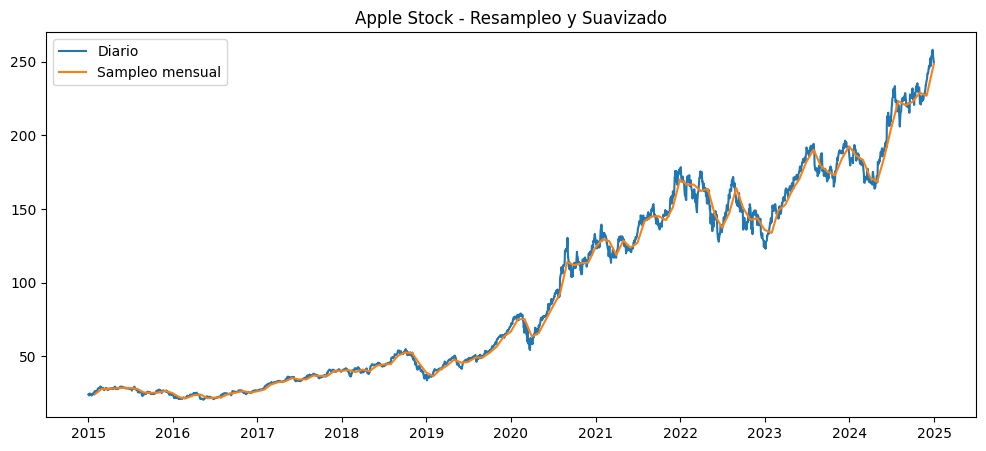

In [7]:
plt.figure(figsize=(12,5))
plt.plot(data_raw['Close'], label="Diario")
plt.plot(data_raw['Close'].resample('ME').mean(), label="Sampleo mensual")
plt.legend()
plt.title("Apple Stock - Resampleo y Suavizado")
plt.show()

**Mensual + suavizado**

In [12]:
# Resampleo mensual
monthly = data_raw['Close'].resample('ME').mean()
monthly.columns =['Close']
# Suavizado ventana 2 y 3
monthly['MA-2']=monthly['Close'].rolling(window=2).mean()
monthly['MA-3']=monthly['Close'].rolling(window=3).mean()

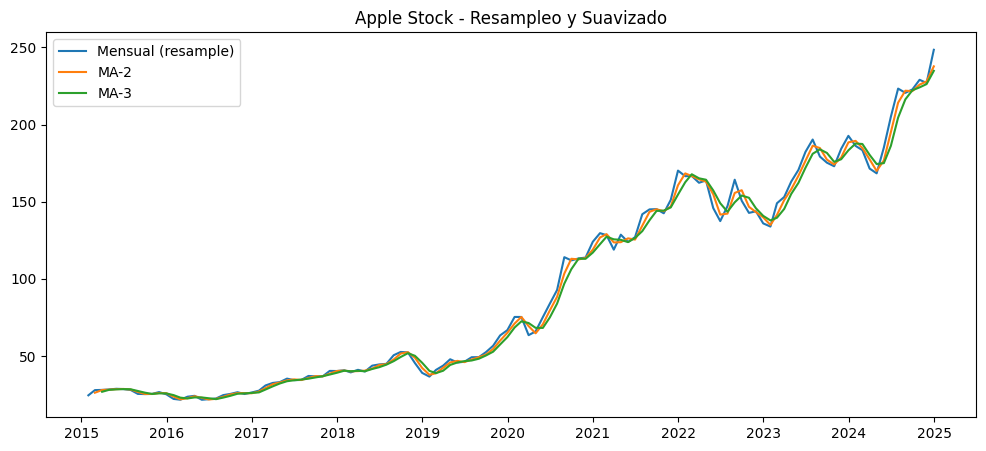

In [13]:
plt.figure(figsize=(12,5))
plt.plot(monthly['Close'], label="Mensual (resample)")
plt.plot(monthly['MA-2'], label="MA-2")
plt.plot(monthly['MA-3'], label="MA-3")
plt.legend()
plt.title("Apple Stock - Resampleo y Suavizado")
plt.show()

### Componentes de la serie

---

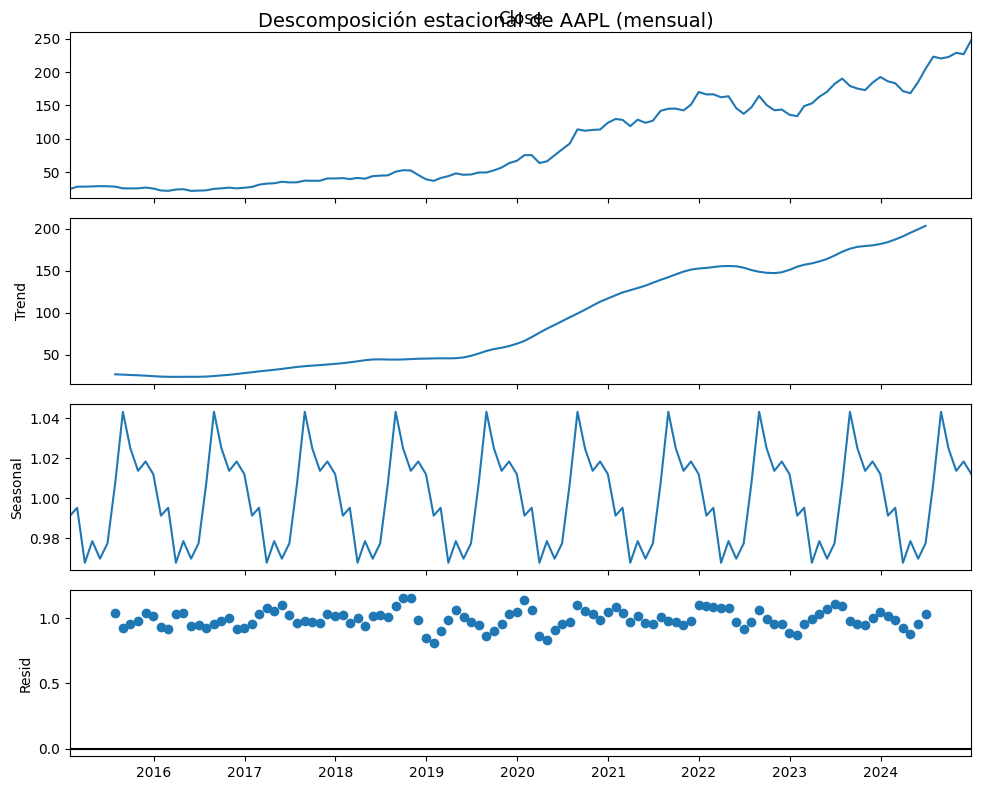

In [ ]:
# Descomposición estacional
resultado = seasonal_decompose(monthly['Close'], model='multiplicative', period=12)

# Graficar los componentes
resultado.plot()
plt.suptitle("Descomposición estacional de AAPL (mensual)", fontsize=14)
plt.show()

## Pronósticos

---

Probemos modelar la serie de datos mensual y veamos algunos de los retos que dataset presenta y los tratamientos que podemos usar 

In [53]:
def make_features(data, max_lag,feature):
    df= data[[feature]].copy()   
    for lag in range(1, max_lag + 1):
        df.loc[:,'lag_{}'.format(lag)] = df[feature].shift(lag)
    return df.dropna()

In [ ]:
params = {
    'objective': 'reg:absoluteerror',  # regresión
    'eval_metric': 'mae',            # métrica de evaluación
    'eta': 0.1,                       # learning rate
    'max_depth': 20,                  # profundidad máxima (5)
    'verbosity': 0
}

def train_xgb_model_n_lags(features_train,target_train,features_test,target_test,data_with_lags,max_lags):
    models=[]
    for n_lags in range(1,max_lags+1):
        print(f"Training for {n_lags} lags")
        
        # Convertir datasets al formato de XGBoost
        dtrain = xgb.DMatrix(features_train.iloc[:,:n_lags], label=target_train)
        dtest = xgb.DMatrix(features_test.iloc[:,:n_lags], label=target_test)


        # Entrenamiento del modelo
        xgb_model = xgb.train(params, dtrain, num_boost_round=200)

        # Predicciones
        preds_xgb = xgb_model.predict(dtest)
        preds_train = xgb_model.predict(dtrain)

        predicted=(
            data_with_lags
            .assign(
                    predicted = lambda df: np.concatenate([preds_train,preds_xgb]),
                    label = lambda df: len(preds_train)*['train'] + len(preds_xgb)*['test']
                )[['predicted','label']]
        )
        # Calcular MAE
        mae_xgb = mean_absolute_error(target_test, preds_xgb)
        print(f"MAE for test: {mae_xgb:.2f} ")
        models.append({'model':xgb_model,'mae_test':mae_xgb,'pred_test':preds_xgb,'preds_train':preds_train,'predicted_serie':predicted}
        )
    return models




    

### **XGB** Serie mensual + $n$ lags 

In [20]:
max_lags=10
data_with_lags=make_features(monthly,max_lags,'Close')
train, test = train_test_split(data_with_lags, shuffle=False, test_size=0.2)
features_train = train.drop(['Close'],axis=1)
target_train = train['Close']
features_test = test.drop(['Close'],axis=1)
target_test = test['Close']

In [23]:
data_with_lags.head()

,Close,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
Date,,,,,,,,,,,
2015-11-30,26.650209,25.474890,25.348508,25.465899,28.039164,28.592038,28.781957,28.358287,28.064097,27.927614,24.552077
2015-12-31,25.215347,26.650209,25.474890,25.348508,25.465899,28.039164,28.592038,28.781957,28.358287,28.064097,27.927614
2016-01-31,22.214184,25.215347,26.650209,25.474890,25.348508,25.465899,28.039164,28.592038,28.781957,28.358287,28.064097
2016-02-29,21.708455,22.214184,25.215347,26.650209,25.474890,25.348508,25.465899,28.039164,28.592038,28.781957,28.358287
2016-03-31,23.659511,21.708455,22.214184,25.215347,26.650209,25.474890,25.348508,25.465899,28.039164,28.592038,28.781957


In [39]:
n_lags=train_xgb_model_n_lags(features_train,target_train,features_test,target_test,data_with_lags,max_lags)

Training for 1 lags
MAE for test: 27.86 
Training for 2 lags
MAE for test: 28.35 
Training for 3 lags
MAE for test: 30.36 
Training for 4 lags
MAE for test: 31.51 
Training for 5 lags
MAE for test: 32.11 
Training for 6 lags
MAE for test: 37.42 
Training for 7 lags
MAE for test: 35.48 
Training for 8 lags
MAE for test: 31.06 
Training for 9 lags
MAE for test: 42.29 
Training for 10 lags
MAE for test: 41.76 


**¿Cuántos rezagos escoger?**

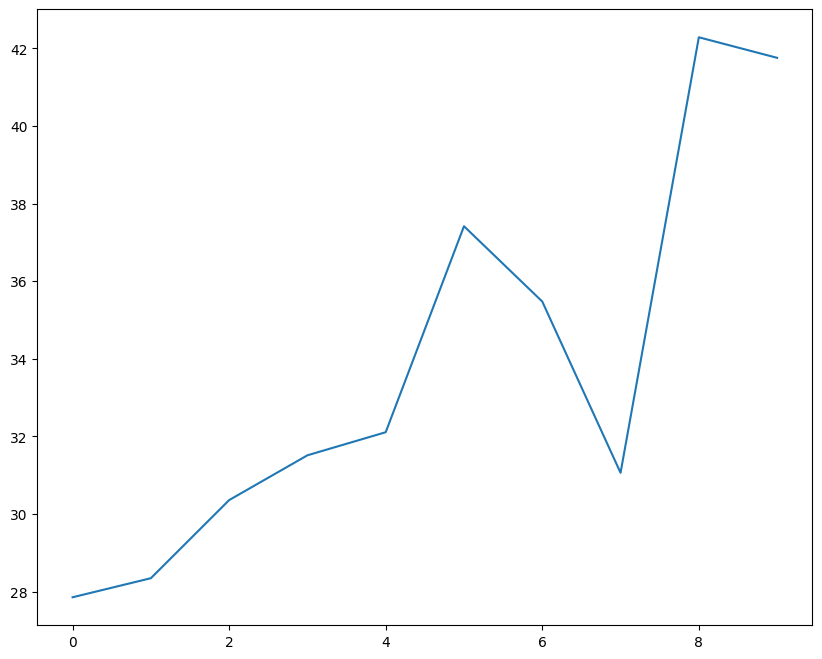

In [40]:
plt.plot([mm['mae_test'] for mm in n_lags])

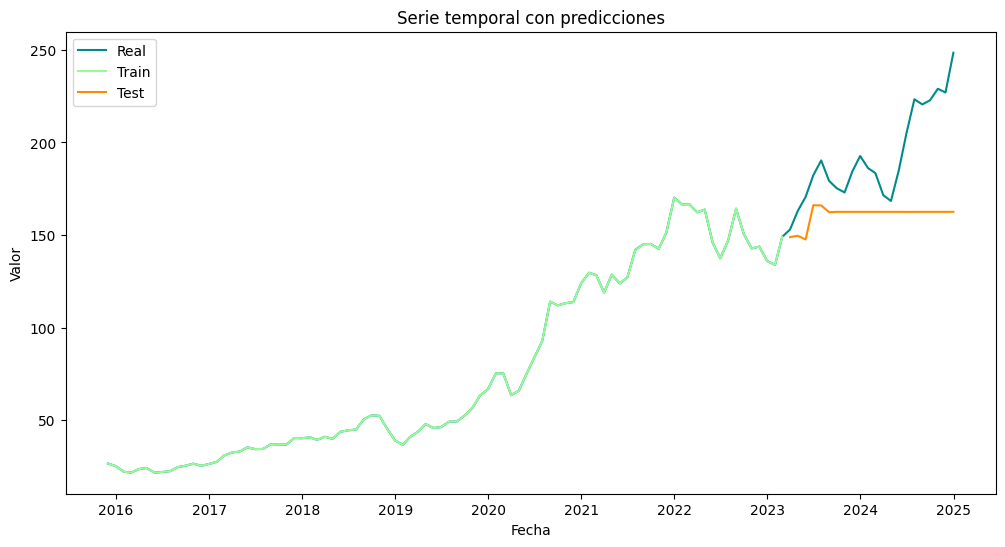

In [41]:
lags_selected=3
plt.figure(figsize=(12,6))
plt.plot(data_with_lags[['Close']], label="Real", color="darkcyan")
plt.plot(n_lags[lags_selected]['predicted_serie'].query('label =="train"')['predicted'], label="Train", color="palegreen")
plt.plot(n_lags[lags_selected]['predicted_serie'].query('label =="test"')['predicted'], label="Test", color="darkorange")
plt.title("Serie temporal con predicciones")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

### XGB Serie mensual con transformación `log`

En ocasiones es conveniente aplicar una transformación logarítmica a una serie de tiempo, especialmente cuando los datos presentan una tendencia exponencial o varianzas crecientes, ya que ayuda a estabilizar la varianza y mejorar el desempeño de los modelos predictivos. Sin embargo, es importante recordar que los pronósticos deben ser transformados nuevamente a la escala original para su correcta interpretación, aplicando la función inversa (exponencial). De lo contrario, los resultados pueden inducir a errores en la comunicación y análisis de las magnitudes reales

In [44]:
monthly['logClose']=np.log(monthly['Close'])

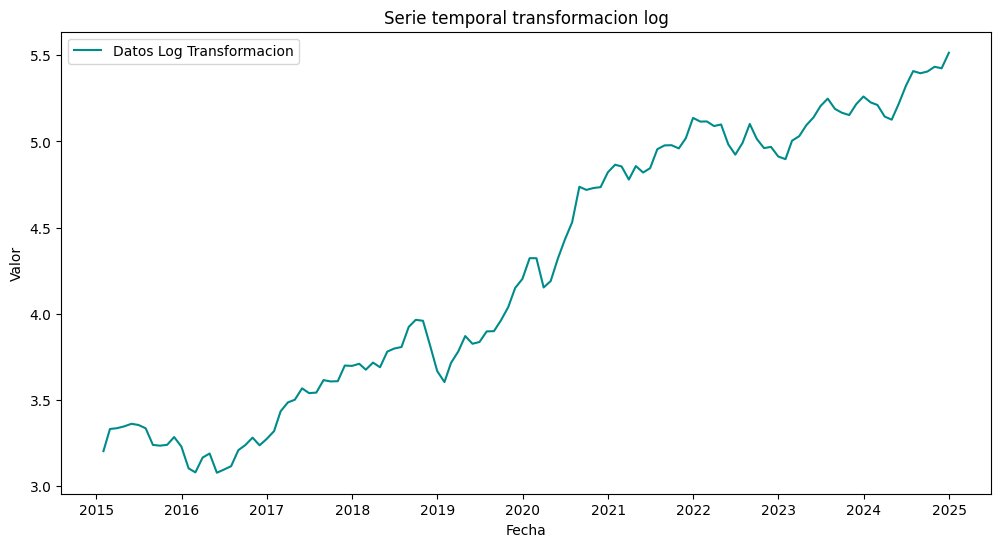

In [45]:
plt.figure(figsize=(12,6))
plt.plot(monthly['logClose'], label="Datos Log Transformacion", color="darkcyan")
plt.title("Serie temporal transformacion log")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

In [54]:
data_with_lags=make_features(monthly,max_lags,'logClose')
train, test = train_test_split(data_with_lags, shuffle=False, test_size=0.2)
features_train = train.drop(['logClose'],axis=1)
target_train = train['logClose']
features_test = test.drop(['logClose'],axis=1)
target_test = test['logClose']

In [55]:
models_log=train_xgb_model_n_lags(features_train,target_train,features_test,target_test,data_with_lags,max_lags)

Training for 1 lags
MAE for test: 0.15 
Training for 2 lags
MAE for test: 0.15 
Training for 3 lags
MAE for test: 0.17 
Training for 4 lags
MAE for test: 0.17 
Training for 5 lags
MAE for test: 0.19 
Training for 6 lags
MAE for test: 0.20 
Training for 7 lags
MAE for test: 0.19 
Training for 8 lags
MAE for test: 0.20 
Training for 9 lags
MAE for test: 0.24 
Training for 10 lags
MAE for test: 0.25 


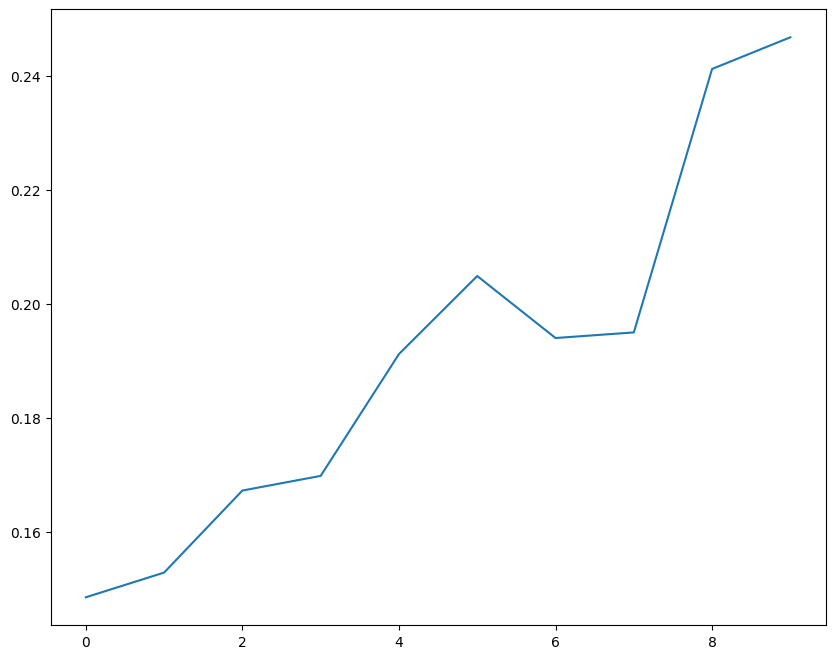

In [56]:
plt.plot([mm['mae_test'] for mm in models_log])

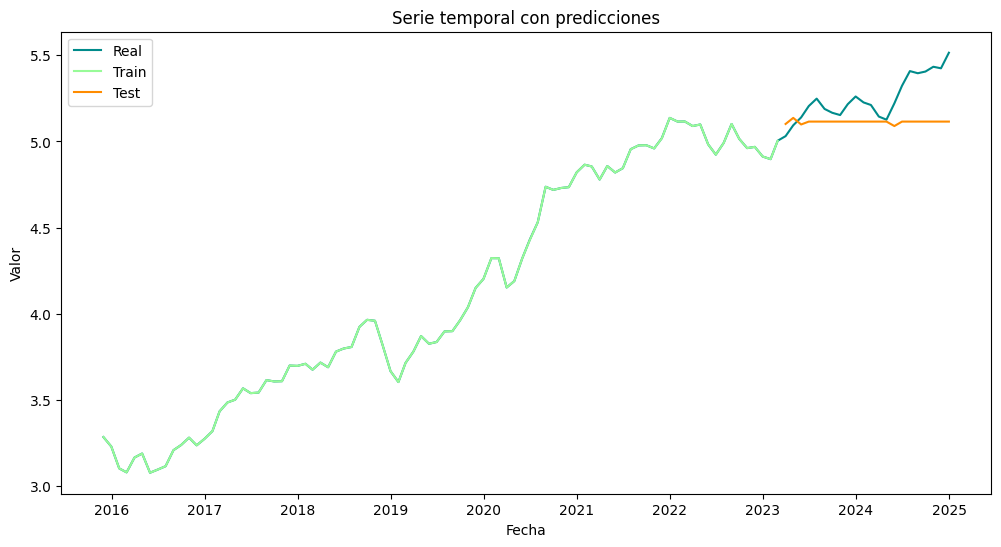

In [59]:
plt.figure(figsize=(12,6))
plt.plot(data_with_lags[['logClose']], label="Real", color="darkcyan")
plt.plot(models_log[0]['predicted_serie'].query('label =="train"')['predicted'], label="Train", color="palegreen")
plt.plot(models_log[0]['predicted_serie'].query('label =="test"')['predicted'], label="Test", color="darkorange")
plt.title("Serie temporal con predicciones")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

### XGBoost + serie estacionaria

La estacionariedad en una serie de tiempo es una propiedad clave que facilita el modelado, ya que implica que las estadísticas como la media y la varianza se mantienen constantes en el tiempo, lo que permite que muchos algoritmos funcionen de manera más eficiente y precisa. Analizar una serie bajo supuestos de estacionariedad ayuda a captar patrones recurrentes y a reducir la influencia de tendencias o ciclos largos que pueden sesgar los resultados. Para lograrla, una técnica común es la diferenciación, que consiste en restar el valor actual de la serie con respecto al inmediato anterior, eliminando tendencias y transformando la serie en una más estable y adecuada para el análisis predictivo.

In [61]:
stationary=monthly[['Close']].diff().dropna()

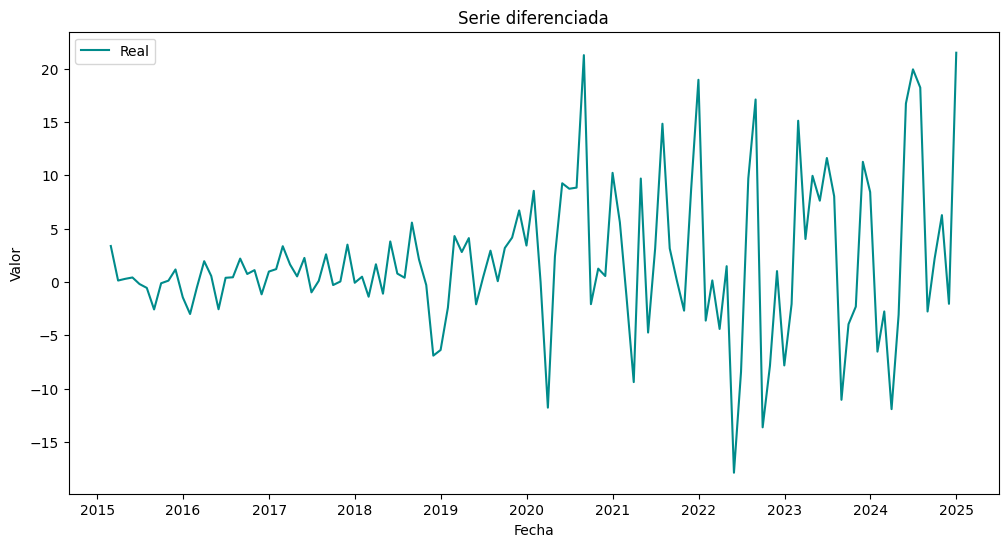

In [62]:
plt.figure(figsize=(12,6))
plt.plot(stationary['Close'], label="Real", color="darkcyan")
plt.title("Serie diferenciada")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

🤔 **¿La serie es estacionaria?**

In [64]:
log_stationary=np.log(monthly[['Close']]).diff().dropna()

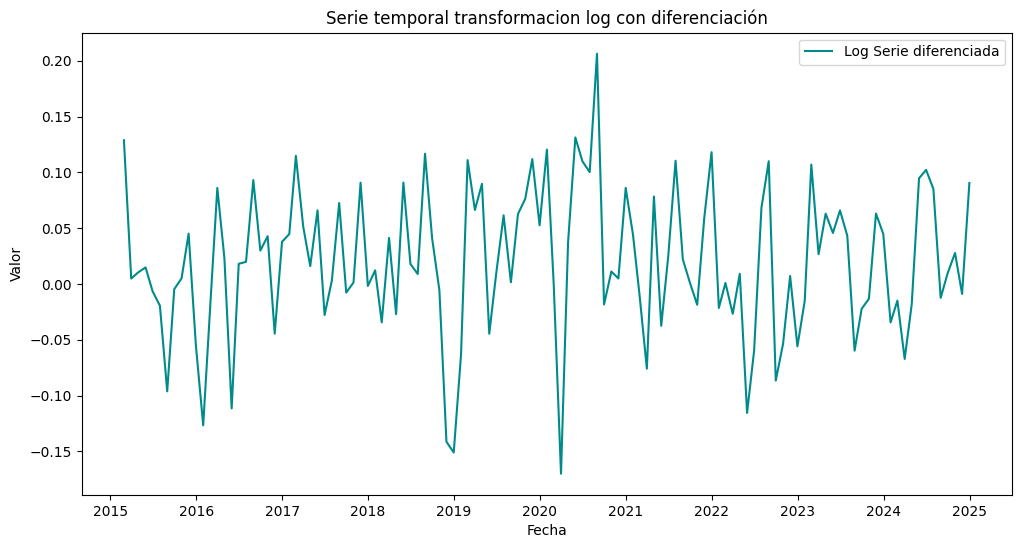

In [65]:
plt.figure(figsize=(12,6))
plt.plot(log_stationary['Close'], label="Log Serie diferenciada", color="darkcyan")
plt.title("Serie temporal transformacion log con diferenciación")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

In [66]:
data_with_lags=make_features(log_stationary,max_lags,'Close')
train, test = train_test_split(data_with_lags, shuffle=False, test_size=0.2)
features_train = train.drop(['Close'],axis=1)
target_train = train['Close']
features_test = test.drop(['Close'],axis=1)
target_test = test['Close']

In [67]:
models_log_stationary=train_xgb_model_n_lags(features_train,target_train,features_test,target_test,data_with_lags,max_lags)

Training for 1 lags
MAE for test: 0.09 
Training for 2 lags
MAE for test: 0.06 
Training for 3 lags
MAE for test: 0.06 
Training for 4 lags
MAE for test: 0.05 
Training for 5 lags
MAE for test: 0.05 
Training for 6 lags
MAE for test: 0.05 
Training for 7 lags
MAE for test: 0.05 
Training for 8 lags
MAE for test: 0.04 
Training for 9 lags
MAE for test: 0.05 
Training for 10 lags
MAE for test: 0.04 


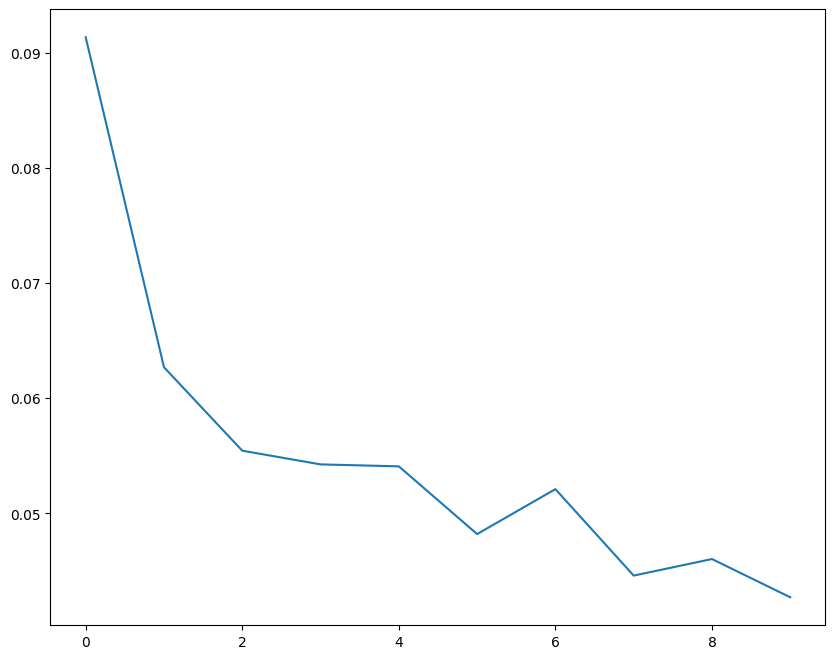

In [68]:
plt.plot([mm['mae_test'] for mm in models_log_stationary])

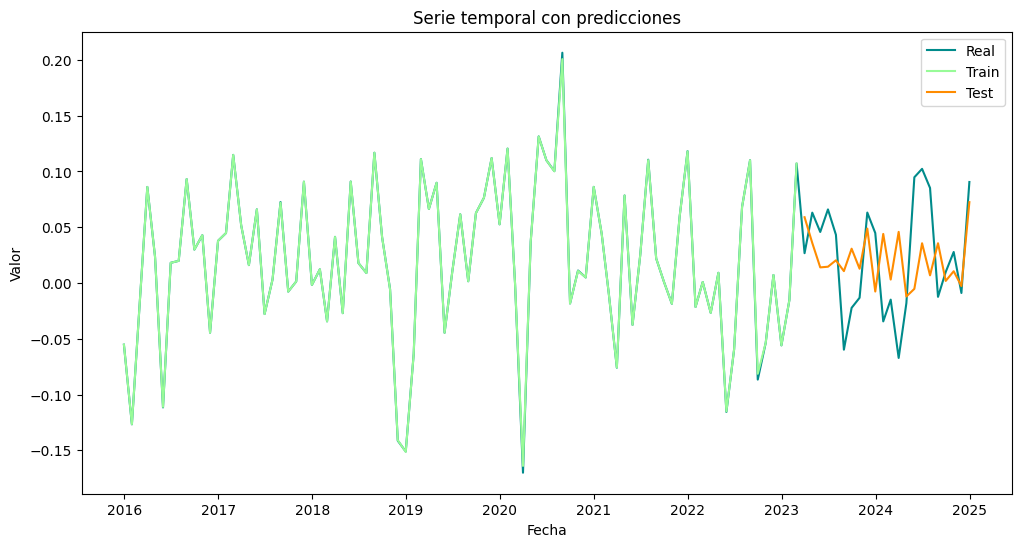

In [69]:
plt.figure(figsize=(12,6))
plt.plot(data_with_lags[['Close']], label="Real", color="darkcyan")
plt.plot(models_log_stationary[9]['predicted_serie'].query('label =="train"')['predicted'], label="Train", color="palegreen")
plt.plot(models_log_stationary[9]['predicted_serie'].query('label =="test"')['predicted'], label="Test", color="darkorange")
plt.title("Serie temporal con predicciones")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

### `Prophet`

Prophet es una herramienta que pronostica series de tiempo separando los datos en tres partes: **tendencia** (cómo crece o disminuye a lo largo del tiempo), **estacionalidad** (patrones que se repiten cada año, mes o semana) y **eventos especiales** (como feriados). Gracias a esto, puede capturar cambios importantes en la serie y hacer predicciones de forma sencilla y comprensible.


In [71]:
monthly[['Close']].reset_index()

,Date,Close
0,2015-01-31,24.552077
1,2015-02-28,27.927614
2,2015-03-31,28.064097
3,2015-04-30,28.358287
4,2015-05-31,28.781957
...,...,...
115,2024-08-31,220.533296
116,2024-09-30,222.721450
117,2024-10-31,228.990358
118,2024-11-30,226.943403


In [73]:
prophet_df=monthly[['Close']].reset_index().copy()
prophet_df.columns = ['ds','y']
n_test =12
train = prophet_df.iloc[:-n_test]
test = prophet_df.iloc[-n_test:]

In [74]:
#Modelo Prophet con estacionalidad anual
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train)

# 3) Horizonte y forecast
future = m.make_future_dataframe(periods=12, freq='M')
fcst = m.predict(future)

17:18:37 - cmdstanpy - INFO - Chain [1] start processing
17:18:37 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


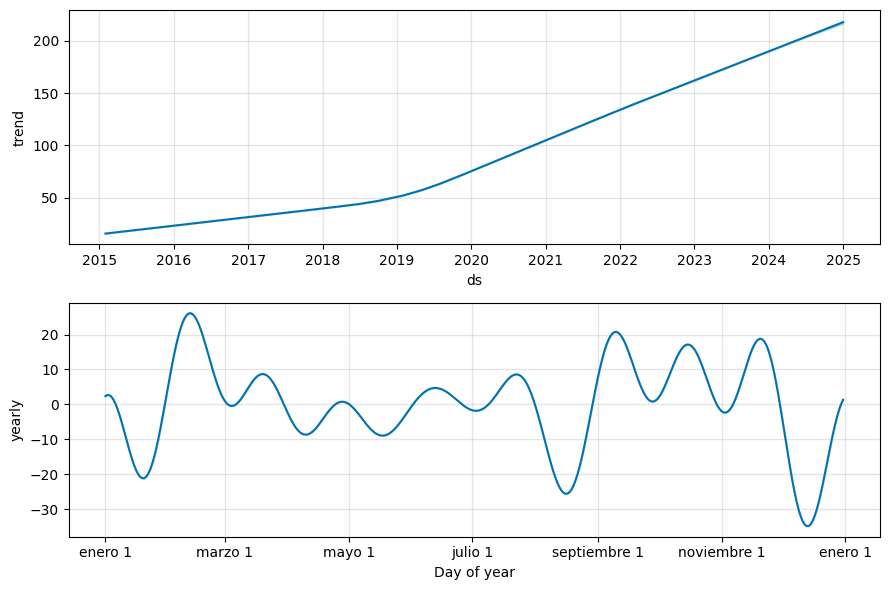

In [78]:
m.plot_components(fcst);

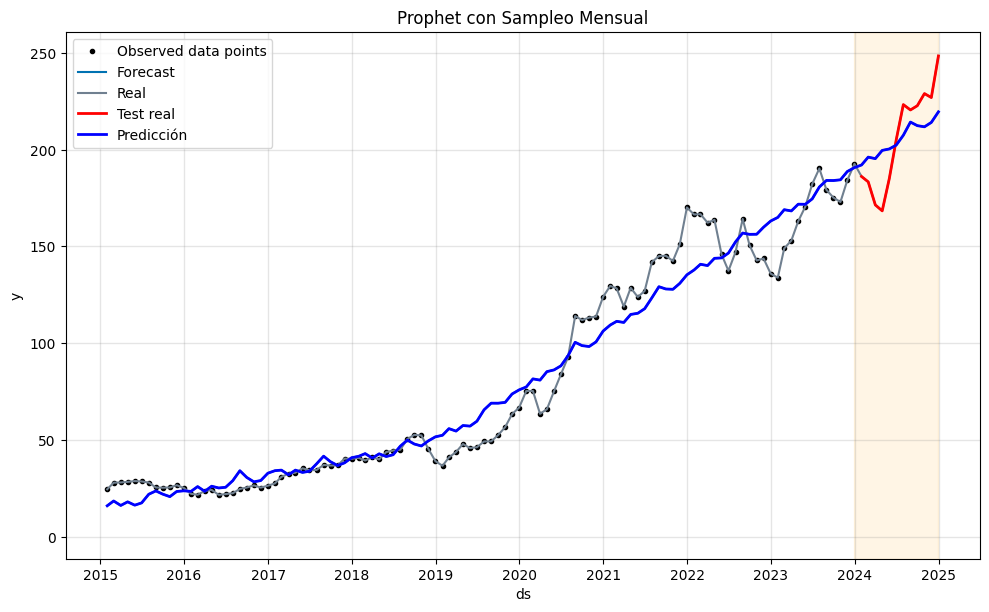

In [76]:
fig = m.plot(fcst)
ax = fig.gca()

# sombrear zona de forecast
last_date = train['ds'].max()
ax.axvspan(last_date, fcst['ds'].max(), color='orange', alpha=0.1)

# remover puntos que dibuja prophet
for coll in ax.collections:
    coll.remove()

# serie real (train + test)
ax.plot(prophet_df['ds'], prophet_df['y'], color='slategray', linewidth=1.5, label="Real")

# test real en color distinto
ax.plot(test['ds'], test['y'], color='red', linewidth=2, label="Test real")

# predicciones de Prophet
ax.plot(fcst['ds'], fcst['yhat'], color='blue', linewidth=2, label="Predicción")

ax.legend()
plt.title('Prophet con Sampleo Mensual')
plt.show()


### 📊 Otros modelos a considerar

| Modelo | Cómo funciona (en pocas palabras) | Bueno para… |
|--------|-----------------------------------|-------------|
| **ARIMA** | Aprende de los valores pasados y de los errores de predicción, quitando la tendencia si es necesario. | Series con una **tendencia clara**, pero sin estacionalidad fuerte. |
| **SARIMA** | Igual que ARIMA, pero además aprende de los **patrones que se repiten cada cierto tiempo** (ej. meses, años). | Series con **tendencia y ciclos regulares**. |
| **Suavizamiento exponencial (Holt-Winters)** | Da más importancia a los datos más recientes y ajusta una línea de tendencia y estacionalidad. | Series con **comportamiento suave**, donde lo más reciente pesa más. |
| **TBATS** | Usa funciones especiales para detectar **varios ciclos al mismo tiempo** (ej. diario, semanal y anual). | Series con **muchas estacionalidades distintas**. |
| **STL decomposition** | Separa la serie en tres partes: tendencia, estacionalidad y ruido, para entender qué pasa. | **Explorar y entender** la serie cuando hay patrones repetidos, aunque no sean perfectos. |


## Para cerrar 💬🤔

----

1. Explica en tus palabras los conceptos de:
    - Serie estacionaria
2. ¿Por qué es necesario realizar transformaciones sobre los datos? y ¿qué cuidados debemos tener?


## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 15](https://discord.com/channels/1081207584104656986/1270074296395497513).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨